# 드라이브 마운트 및 경로추가

In [1]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [2]:
%cd /content/drive/MyDrive/ultralytics/ultralytics
%ls

/content/drive/MyDrive/ultralytics/ultralytics
assets/                      hub/               __pycache__/       solutions/  yolov8n.pt
cfg/                         __init__.py        rtdetr-l.pt        trackers/   yolov8n-seg.pt
data/                        models/            rtdetr-x.pt        utils/      yolov8s.pt
engine/                      NH01_YOLO.ipynb    runs/              wandb/
FOOD_DETECT/                 NHC014_YOLO.ipynb  runs_food_rtdetr/  yolo11n.pt
Food_Detection_RTDETR.ipynb  NHC_DETECT/        runs_food_yolo/    yolo11s.pt
Food_Detection_YOLO.ipynb    nn/                runs_HNC_yolo/     yolov8m.pt


In [ ]:
#!git clone https://github.com/ultralytics/ultralytics.git

Cloning into 'ultralytics'...
remote: Enumerating objects: 43334, done.
remote: Counting objects: 100% (1079/1079), done.
remote: Compressing objects: 100% (696/696), done.
remote: Total 43334 (delta 739), reused 610 (delta 378), pack-reused 42255 (from 1)
Receiving objects: 100% (43334/43334), 37.59 MiB | 14.76 MiB/s, done.
Resolving deltas: 100% (32083/32083), done.
Updating files: 100% (663/663), done.


In [ ]:
#!mkdir /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data
#!cp /content/drive/MyDrive/ultralytics/ultralytics/cfg/default.yaml /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/default.yaml
#!cp /content/drive/MyDrive/ultralytics/ultralytics/cfg/models/rt-detr/rtdetr-l.yaml /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr-l.yaml
#!cp /content/drive/MyDrive/ultralytics/ultralytics/cfg/datasets/coco8.yaml /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml

In [3]:
import sys
sys.path.append('/content/drive/MyDrive/ultralytics')
sys.path.append('/content/drive/MyDrive/ultralytics/ultralytics')  # Add the folder to sys.path

In [4]:
sys.path

['/content',
 '/env/python',
 '/usr/lib/python311.zip',
 '/usr/lib/python3.11',
 '/usr/lib/python3.11/lib-dynload',
 '',
 '/usr/local/lib/python3.11/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.11/dist-packages/IPython/extensions',
 '/usr/local/lib/python3.11/dist-packages/setuptools/_vendor',
 '/root/.ipython',
 '/content/drive/MyDrive/ultralytics',
 '/content/drive/MyDrive/ultralytics/ultralytics']

In [10]:
import os
import yaml
import torch

`'/content/drive/MyDrive/ultralytics/ultralytics/__init__.py'` 파일이 있으므로 디렉토리가 패키지로 인식된다는 뜻.

In [6]:
# Model arguments
data_path = "/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 데이터 압축 풀기

In [ ]:
#!unzip -O cp949 -q /content/drive/MyDrive/yolov8/custom_data/FOOD.zip -d /content/drive/MyDrive/yolov8/custom_data/FOOD
# -O cp949 부분은 한글깨짐 방지 코드
# -q 는 조용히

#로거 세팅

In [5]:
from google.colab import userdata
wandb_api = userdata.get('WANDB_API')

import wandb
wandb.login(key=wandb_api)

wandb: Currently logged in as: so0916a. Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True



# 학습코드 테스트


- 레퍼런스: https://docs.ultralytics.com/reference/models/rtdetr/train/
<br><br>

- RT-DETR 모델의 경우, model.tune() 할 수 없으며, 직접 training script 안에서 hyperparameter들을 adjust 해야함.
  - ultralytics reference: https://github.com/ultralytics/ultralytics/issues/14388

<br><br>
- AutomaticMixedPrecision 혼합정밀교육 사용
  - 레퍼런스: https://docs.ultralytics.com/ko/guides/model-training-tips/#mixed-precision-training
  - AMP를 사용하면 사용자가 AMP 훈련을 쉽게 활성화하여 Tensor Core GPU에서 최대 50%까지 더 높은 성능과 메모리 절약을 실현할 수 있다고 함.
  - 기본적으로 지원되는 torch.cuda.amp API를 사용하여 AMP는 혼합 정밀도에 대한 편의 메서드를 제공하며, 일부 연산은 torch.float32(float) 데이터 유형을 사용하고 다른 연산은 torch.float16(half)을 사용
  - 선형 레이어 및 합성곱과 같은 일부 연산은 float16에서 훨씬 빠름.축소와 같은 다른 연산은 종종 float32의 동적 범위가 필요.
    - https://github.com/ultralytics/yolov5/issues/557
  - Sometimes AMP can cause instability in memory management. You can try disabling it if reducing the batch size or image size doesn’t help.


- Removing albumentations from model
  - https://github.com/ultralytics/ultralytics/issues/4254

- WandB를 이용한 Sweep 시도하였으나, 제대로 코드가 돌아가지 않음
  - GPU 메모리 부족으로 sweep 중단 후, manual로 일단 학습 진행

In [ ]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 32.7/235.7 GB disk)


In [ ]:
from ultralytics import RTDETR

# Load a COCO-pretrained RT-DETR-l model
model_l = RTDETR("rtdetr-l.pt")
# Display model information (optional)
model_l.info()

rt-detr-l summary: 673 layers, 32,970,476 parameters, 0 gradients


(673, 32970476, 0, 0.0)

In [6]:
import ultralytics
from ultralytics import RTDETR
model_X = RTDETR("/content/drive/MyDrive/ultralytics/ultralytics/rtdetr-x.pt")

In [7]:
model_X.info()

rt-detr-x summary: 867 layers, 67,467,852 parameters, 0 gradients


(867, 67467852, 0, 0.0)

In [ ]:
from ultralytics.models.rtdetr.train import RTDETRTrainer

# RTDETRTrainer가 정상적으로 불러와졌는지 확인
print(RTDETRTrainer)

<class 'ultralytics.models.rtdetr.train.RTDETRTrainer'>


In [ ]:
from ultralytics.models.rtdetr import RTDETRValidator

args = dict(model="/content/drive/MyDrive/ultralytics/ultralytics/runs_food_rtdetr/detect/train9-2/weights/best.pt",
            data="'/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml")
validator = RTDETRValidator(args=args)
validator()

In [ ]:
import inspect
# Check if the RTDETRTrainer is being loaded from the correct path
print(inspect.getfile(RTDETRTrainer))

/content/drive/MyDrive/ultralytics/ultralytics/models/rtdetr/train.py


## 테스팅 학습 Train1




In [ ]:
run = wandb.init(project="rt-detr-manual",
                 name = 'train1',
                 id= 'hqmlsgd6',
                 resume = 'allow')

In [ ]:
def main(model):

    # Define the arguments for the trainer
    args = dict(name='train1',
                data=data_path,
                imgsz=1088,
                epochs=10,  # Increased epochs for further learning
                batch=16,
                augment=False,
                workers=4,
                device=device,
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir=os.path.join(save_path, 'train1')
    )

    wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting

    results = model_l.train(**args) # Pass args during training

if __name__ == "__main__":
  main(model_l)

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.57 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=rtdetr-l.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train13, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frame

100%|██████████| 755k/755k [00:00<00:00, 15.2MB/s]


Overriding model.yaml nc=80 with nc=1
WARNING ⚠️ no model scale passed. Assuming scale='l'.

                   from  n    params  module                                       arguments                     
  0                  -1  1     25248  ultralytics.nn.modules.block.HGStem          [3, 32, 48]                   
  1                  -1  6    155072  ultralytics.nn.modules.block.HGBlock         [48, 48, 128, 3, 6]           
  2                  -1  1      1408  ultralytics.nn.modules.conv.DWConv           [128, 128, 3, 2, 1, False]    
  3                  -1  6    839296  ultralytics.nn.modules.block.HGBlock         [128, 96, 512, 3, 6]          
  4                  -1  1      5632  ultralytics.nn.modules.conv.DWConv           [512, 512, 3, 2, 1, False]    
  5                  -1  6   1695360  ultralytics.nn.modules.block.HGBlock         [512, 192, 1024, 5, 6, True, False]
  6                  -1  6   2055808  ultralytics.nn.modules.block.HGBlock         [1024, 192, 1024, 5, 

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 8062 images, 25 backgrounds, 0 corrupt: 100%|██████████| 8062/8062 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed


...

                   all       1595       1707      0.645       0.53      0.557      0.236



10 epochs completed in 1.013 hours.
Optimizer stripped from runs/detect/train13/weights/last.pt, 66.1MB
Optimizer stripped from runs/detect/train13/weights/best.pt, 66.1MB

Validating runs/detect/train13/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
rt-detr-l summary: 502 layers, 31,985,795 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:18<00:00,  2.73it/s]


                   all       1595       1707      0.672      0.649      0.639      0.274
Speed: 0.3ms preprocess, 6.8ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to runs/detect/train13


lr/pg0,▃▆█▇▆▅▄▃▂▁
lr/pg1,▃▆█▇▆▅▄▃▂▁
lr/pg2,▃▆█▇▆▅▄▃▂▁
metrics/mAP50(B),▄▁█▃▃▃▃▃▃█
metrics/mAP50-95(B),▁▃█▂▂▂▂▂▂█
metrics/precision(B),▅▁█▇▇▇▇▇▇█
metrics/recall(B),▄▃█▁▁▁▁▁▁█
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/cls_loss,█▂▁▁▁


In [ ]:
model_val1 = RTDETR("/content/drive/MyDrive/ultralytics/ultralytics/runs_food_rtdetr/detect/train1/weights/best.pt")
metrics = model_val1.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
rt-detr-l summary: 502 layers, 31,985,795 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:36<00:00,  2.73it/s]


                   all       1595       1707      0.673      0.649      0.641      0.275
Speed: 0.7ms preprocess, 11.6ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to runs/detect/val


{'metrics/precision(B)': 0.6727309682844044,
 'metrics/recall(B)': 0.6490919742237844,
 'metrics/mAP50(B)': 0.6405172170076658,
 'metrics/mAP50-95(B)': 0.27465608296448596,
 'fitness': 0.31124219636880396}

## Train2

In [ ]:
run = wandb.init(project="Food_rt-detr-manual",
                 name = 'train2',
                 id= '4u4iqzv1',
                 resume = 'allow')

In [ ]:
def main(model):

    # Define the arguments for the trainer
    args = dict(name='train2',
                data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml",
                imgsz=1088,
                epochs=30,  # Increased epochs for further learning
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir=os.path.join(save_path, 'train2')
    )

    wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting

    results = model_l.train(**args) # Pass args during training

if __name__ == "__main__":
  # It's generally safe to disable deterministic algorithms for training
  torch.use_deterministic_algorithms(False)
  main(model_l)

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.58 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=rtdetr-l.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 8062 images, 25 backgrounds, 0 corrupt: 100%|██████████| 8062/8062 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed


albumentations: 


/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.24 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

...

Optimizer stripped from runs/detect/train2/weights/best.pt, 66.1MB

Validating runs/detect/train2/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
rt-detr-l summary: 502 layers, 31,985,795 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:18<00:00,  2.69it/s]


                   all       1595       1707      0.673      0.656      0.655      0.383
Speed: 0.3ms preprocess, 6.7ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs/detect/train2


wandb: WARNING Tried to log to step 30 that is less than the current step 31. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 30 that is less than the current step 31. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 30 that is less than the current step 31. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 30 that is less than the current step 31. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 30 that is less than the current step 31. Steps must be monotonically increasing, so this data will be ignored. See https://wand

lr/pg0,9e-05
lr/pg1,9e-05
lr/pg2,9e-05
metrics/mAP50(B),0.61678
metrics/mAP50-95(B),0.27822
metrics/precision(B),0.62038
metrics/recall(B),0.6819
model/GFLOPs,107.992
model/parameters,32808131
model/speed_PyTorch(ms),7.086
train/cls_loss,NaN


In [ ]:
model_val2 = RTDETR("/content/drive/MyDrive/ultralytics/ultralytics/runs_food_rtdetr/detect/train2/weights/best.pt")
metrics = model_val2.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
rt-detr-l summary: 502 layers, 31,985,795 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:38<00:00,  2.62it/s]


                   all       1595       1707      0.674      0.656      0.658      0.385
Speed: 0.4ms preprocess, 12.1ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs/detect/val


{'metrics/precision(B)': 0.6742151615557291,
 'metrics/recall(B)': 0.6558906582888009,
 'metrics/mAP50(B)': 0.6584779282127979,
 'metrics/mAP50-95(B)': 0.3846479124348883,
 'fitness': 0.4120309140126792}

## train 실행 중 발생한 메세지 해결



```
/usr/local/lib/python3.10/dist-packages/torch/autograd/graph.py:769: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:83.)

```
- Thread reference: https://github.com/ultralytics/ultralytics/issues/5978
<br><br>
- PyTorch에서 CUDA 관련 연산 중 grid_sampler_2d_backward_cuda 함수가 비결정적(Non-deterministic)이기 발생.
  - 이 연산은 동일한 입력을 주더라도 여러 번 실행할 때 약간씩 다른 결과를 반환할 수 있다는 의미
  - `torch.use_deterministic_algorithms(True, warn_only=True)`를 설정했기 때문에, PyTorch는 모든 연산을 결정적으로 만들려 하지만, 이 특정 연산은 그러한 기능이 없다는 경고입니다. 결정론적 연산이 반드시 필요하지 않다면, `torch.use_deterministic_algorithms(False)`로 설정해 경고를 피할 수 있습니다.
<br><br>
- args 변수 지정에, 아래와 같이 넣어 메세지 해결
   - ```
   deterministic=False
  ```

## Train 3

- 지난 학습에서 뜨는 duplicate label 메세지 warning
  - txt파일들에 중복 데이터 라인 제거 완료

In [ ]:
run = wandb.init(project="Food_rt-detr-manual",
                 name = 'train3')

In [ ]:
def main():

    # Define the arguments for the trainer
    args = dict(name='train3',
                data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml",
                imgsz=1088,
                epochs=50,  # Increased epochs for further learning
                batch=16,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                augment=False,
                deterministic=False,
                amp=True,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                close_mosaic=0,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir="/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train3"
    )

    wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting

    results = model_l.train(**args) # Pass args during training

if __name__ == "__main__":
  # It's generally safe to disable deterministic algorithms for training
  torch.use_deterministic_algorithms(False)
  main()

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.58 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=rtdetr-l.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=False, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 8062 images, 25 backgrounds, 0 corrupt: 100%|██████████| 8062/8062 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed
albumentations: 



val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed


...

                   all       1595       1707      0.615      0.602      0.565      0.293



50 epochs completed in 4.381 hours.
Optimizer stripped from runs/detect/train3/weights/last.pt, 66.1MB
Optimizer stripped from runs/detect/train3/weights/best.pt, 66.1MB

Validating runs/detect/train3/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
rt-detr-l summary: 502 layers, 31,985,795 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:17<00:00,  2.93it/s]


                   all       1595       1707      0.632      0.649      0.627      0.345
Speed: 0.7ms preprocess, 6.4ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to runs/detect/train3


lr/pg0,▃▆███▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁
lr/pg1,▃▆███▇▇▇▇▇▇▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁
lr/pg2,▃▆███▇▇▇▇▇▇▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁
metrics/mAP50(B),█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█
metrics/mAP50-95(B),█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█
metrics/precision(B),█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█
metrics/recall(B),█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/cls_loss,▁█


In [ ]:
from ultralytics import RTDETR
model_val3 = RTDETR("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train3/weights/best.pt")
metrics = model_val3.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml")
metrics.results_dict

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
rt-detr-l summary: 502 layers, 31,985,795 parameters, 0 gradients


100%|██████████| 755k/755k [00:00<00:00, 14.6MB/s]
val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [01:40<00:00,  1.01s/it]


                   all       1595       1707      0.631      0.646      0.625      0.346
Speed: 0.7ms preprocess, 11.5ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to runs/detect/val3


{'metrics/precision(B)': 0.6306300232424462,
 'metrics/recall(B)': 0.6461628588166374,
 'metrics/mAP50(B)': 0.6254783852746959,
 'metrics/mAP50-95(B)': 0.34582981010464037,
 'fitness': 0.3737946676216459}

## Train 4

- epoch 40, batch 8로 돌려보기
- lr0=lr0=0.0001, lrf=0.01 추가
- weight decay 0.001 추가
- close_mosaic=0 추가

<br>

- 레퍼런스: https://stackoverflow.com/questions/67707828/how-to-get-every-seconds-gpu-usage-in-python
- GPU 상태 확인 추가:
  - train 함수에서 모델 학습 전 nvidia-smi를 이용해 GPU 메모리와 사용률을 출력.


In [ ]:
run = wandb.init(project="Food_rt-detr-manual",
                 name = 'train4')

wandb: Currently logged in as: so0916a. Use `wandb login --relogin` to force relogin


In [ ]:
def main():

    # Define the arguments for the trainer
    args = dict(data=data_path,  # Custom dataset configuration file
                model=model_path,  # Model configuration file
                imgsz=1088,  # Image size for training
                epochs=40,  # Number of epochs to train the model
                batch=8,
                augment=False,
                workers=4,
                device=device,
                optimizer='AdamW',
                weight_decay=0.001,
                lr0=0.0001,  # Initial learning rate
                lrf=0.01,
                verbose=True,
                seed=0,
                deterministic=False,
                hsv_h=0.0,  # Disable hue shift
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=0.0,  # Disable rotation
                translate=0.0,  # Disable translation
                scale=0.0,  # Disable scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                crop_fraction=1.0, # 1.0 means no crop,
                close_mosaic=0,
                resume=False,
                amp=True,
                auto_augment= None,
                save_dir=save_path)

    wandb.config.update(args)

    # Initialize the trainer with the specified arguments
    trainer = RTDETRTrainer(overrides=args)

    # Call the train function to start training
    train(trainer)

def train(trainer):

    # Get GPU device count
    deviceCount = nvidia_smi.nvmlDeviceGetCount()

    # Display GPU utilization and memory information before training
    print("GPU Status Before Training:")
    for i in range(deviceCount):
        handle = nvidia_smi.nvmlDeviceGetHandleByIndex(i)
        util = nvidia_smi.nvmlDeviceGetUtilizationRates(handle)
        mem = nvidia_smi.nvmlDeviceGetMemoryInfo(handle)
        print(f"|Device {i}| Mem Free: {mem.free/1024**2:5.2f}MB / {mem.total/1024**2:5.2f}MB | "
              f"gpu-util: {util.gpu/100.0:3.1%} | gpu-mem: {util.memory/100.0:3.1%} |")

    # Train the model
    trainer.train()

    # Display GPU utilization and memory information after training
    print("GPU Status After Training:")
    for i in range(deviceCount):
        handle = nvidia_smi.nvmlDeviceGetHandleByIndex(i)
        util = nvidia_smi.nvmlDeviceGetUtilizationRates(handle)
        mem = nvidia_smi.nvmlDeviceGetMemoryInfo(handle)
        print(f"|Device {i}| Mem Free: {mem.free/1024**2:5.2f}MB / {mem.total/1024**2:5.2f}MB | "
              f"gpu-util: {util.gpu/100.0:3.1%} | gpu-mem: {util.memory/100.0:3.1%} |")

if __name__ == "__main__":
    try:
        nvidia_smi.nvmlInit()
        main()
    except nvidia_smi.nvml.NVMLError as error:
        print(f"Failed to initialize NVML: {str(error)}")

engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train3/weights/best.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml, epochs=40, time=None, patience=100, batch=8, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train4, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=False, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels... 7528 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7528/7528 [09:04<00:00, 13.83it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed


train: New cache created: /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache
albumentations: 


/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 1.4.18 (you have 1.4.15). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

...

                   all       1595       1707      0.681      0.492      0.515      0.318

40 epochs completed in 8.834 hours.
Optimizer stripped from runs/detect/train4/weights/last.pt, 66.1MB
Optimizer stripped from runs/detect/train4/weights/best.pt, 66.1MB

Validating runs/detect/train4/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
rtdetr-l summary: 502 layers, 31,985,795 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:43<00:00,  2.29it/s]


                   all       1595       1707       0.65      0.525      0.544       0.32
Speed: 0.6ms preprocess, 23.2ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs/detect/train4


lr/pg0,█▅▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr/pg1,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
lr/pg2,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
metrics/mAP50(B),▁▃▃▅▆▆▆▆▆▆▇█▇▇▇▇██▇▇▇▇▇██▇█▇▇▇▇▇▇▇▇▇▇▇▇█
metrics/mAP50-95(B),▁▁▄▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇██████████████████
metrics/precision(B),▁▁▃▄▃▇█▆▆▆▆▆█▇▇██▇▅▅▅▆▆▇▆▆█▆▅▇▇▇▆▇▆▇█▇▇▆
metrics/recall(B),▁▁▂▃▇▅▅▅▅▆▆▇▇▇▇▆▇▆█▆█▇█▇█▇▆▆█▇▇▇█▇▇▇▆▆▆█
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/cls_loss,█▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁


GPU Status After Training:
|Device 0| Mem Free: 20612.88MB / 23034.00MB | gpu-util: 0.0% | gpu-mem: 0.0% |


In [ ]:
from ultralytics import RTDETR

model_val4 = RTDETR("/content/drive/MyDrive/ultralytics/ultralytics/runs_food_rtdetr/detect/train4/weights/best.pt")
metrics = model_val4.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
rtdetr-l summary: 502 layers, 31,985,795 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:38<00:00,  2.63it/s]


                   all       1595       1707      0.657      0.518      0.545       0.32
Speed: 0.4ms preprocess, 12.1ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to runs/detect/val2


{'metrics/precision(B)': 0.657111407759291,
 'metrics/recall(B)': 0.5184534270650264,
 'metrics/mAP50(B)': 0.5445374091726651,
 'metrics/mAP50-95(B)': 0.31955037478295745,
 'fitness': 0.3420490782219282}

In [ ]:
model = RTDETR("/content/drive/MyDrive/ultralytics/ultralytics/runs_food_rtdetr/detect/train4/weights/best.pt")

# Run inference with the custom data trained RT-DETR-l model on the test x-ray image.
results = model("/content/drive/MyDrive/ultralytics/ultralytics/assets/test_full.jpg")


image 1/1 /content/drive/MyDrive/ultralytics/ultralytics/assets/test_full.jpg: 1088x1088 1 Food, 39.3ms
Speed: 16.0ms preprocess, 39.3ms inference, 13.9ms postprocess per image at shape (1, 3, 1088, 1088)


In [ ]:
results[0]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'Food'}
obb: None
orig_img: array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
orig_shape: (1080, 1920)
p

In [ ]:
results[0].boxes.xyxy

tensor([[671.4656, 448.8667, 855.0362, 761.3859]], device='cuda:0')

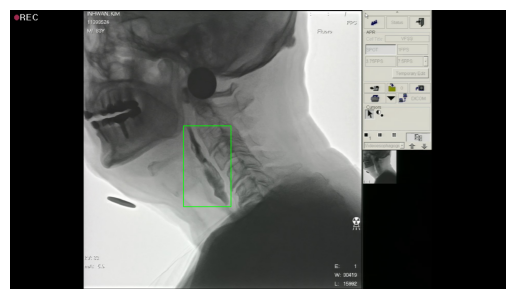

In [ ]:
import matplotlib.pyplot as plt
import cv2

# 원본 이미지를 가져오기
image = results[0].orig_img

# 탐지된 모든 박스에 대해 루프
for box in results[0].boxes.xyxy:
    x1, y1, x2, y2 = map(int, box[:4])
    # 이미지에 박스 그리기
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

# 이미지 시각화
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
# 결과 이미지를 파일로 저장
plt.savefig(fname="/content/drive/MyDrive/ultralytics/ultralytics/runs/predict/testfull_train4.jpg")
# 저장후, 보여주기. 순서가 바뀌면 빈 화면 저장하게 됌.
plt.show()

## Train 5: earlystopping옵션이 best.pt 저장 안함


In [ ]:
run = wandb.init(project="Food_rt-detr-manual",
                 name = 'train5')

In [ ]:
def main():

    args = dict(data=data_path,  # Custom dataset configuration file
                model="/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train4/weights/best.pt",  # Model configuration file
                imgsz=1088,  # Image size for training
                epochs=40,  # Number of epochs to train the model
                batch=8,
                augment=False,
                workers=4,
                device=device,
                optimizer='AdamW',
                weight_decay=0.001, # 새로 추가
                lr0=0.0001,  # Initial learning rate
                lrf=0.01,
                verbose=True,
                seed=0,
                deterministic=False,
                hsv_h=0.0,  # Disable hue shift
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=0.0,  # Disable rotation
                translate=0.0,  # Disable translation
                scale=0.0,  # Disable scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                crop_fraction=1.0, # 1.0 means no crop,
                close_mosaic=0,
                resume=False,
                amp=True,
                auto_augment= None,
                save_dir="/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train5")

    wandb.config.update(args)

    # Initialize the trainer with the specified arguments
    trainer = RTDETRTrainer(overrides=args)

    # Call the train function to start training
    train(trainer)

def train(trainer):

    # Train the model
    trainer.train()

if __name__ == "__main__":
  main()

engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train4/weights/best.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml, epochs=50, time=None, patience=5, batch=8, imgsz=1088, save=False, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train5, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=False, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop

100%|██████████| 755k/755k [00:00<00:00, 15.4MB/s]


TensorBoard: Start with 'tensorboard --logdir runs/detect/train5', view at http://localhost:6006/
WARNING ⚠️ no model scale passed. Assuming scale='l'.

                   from  n    params  module                                       arguments                     
  0                  -1  1     25248  ultralytics.nn.modules.block.HGStem          [3, 32, 48]                   
  1                  -1  6    155072  ultralytics.nn.modules.block.HGBlock         [48, 48, 128, 3, 6]           
  2                  -1  1      1408  ultralytics.nn.modules.conv.DWConv           [128, 128, 3, 2, 1, False]    
  3                  -1  6    839296  ultralytics.nn.modules.block.HGBlock         [128, 96, 512, 3, 6]          
  4                  -1  1      5632  ultralytics.nn.modules.conv.DWConv           [512, 512, 3, 2, 1, False]    
  5                  -1  6   1695360  ultralytics.nn.modules.block.HGBlock         [512, 192, 1024, 5, 6, True, False]
  6                  -1  6   2055808  ultral

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 7528 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7528/7528 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed


...


      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


       6/50      17.8G        nan        nan        nan          9       1088:   0%|          | 1/941 [00:00<06:50,  2.29it/s]wandb: WARNING Tried to log to step 5 that is less than the current step 27. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
       6/50      17.8G        nan        nan        nan          9       1088: 100%|██████████| 941/941 [06:18<00:00,  2.49it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  15%|█▌        | 15/100 [00:02<00:14,  6.01it/s]wandb: WARNING Tried to log to step 6 that is less than the current step 27. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 6 that is less than the current step 27. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log da

                   all       1595       1707    0.00194      0.359    0.00278   0.000514
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 1, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



6 epochs completed in 0.752 hours.


lr/pg0,5e-05
lr/pg1,5e-05
lr/pg2,5e-05
metrics/mAP50(B),0.5408
metrics/mAP50-95(B),0.32159
metrics/precision(B),0.66187
metrics/recall(B),0.52548
model/GFLOPs,0
model/parameters,32808131
model/speed_PyTorch(ms),24.814
train/cls_loss,0.25026


- Patience를 넣어 early stopping을 시도하면, best.pt 와 last.pt가  save 되지 않을 수 있음
- 레퍼런스: https://github.com/ultralytics/ultralytics/issues/3736

In [ ]:
run = wandb.init(project="Food_rt-detr-manual",
                 name = 'train5-2')

In [ ]:
def main():

    # Define the arguments
    args = dict(name='train5-2',
                data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml",
                imgsz=1088,
                epochs=80,  # Increased epochs for further learning
                batch=16,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                augment=False,
                deterministic=False,
                amp=True,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                close_mosaic=0,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir="/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train5-2"

    )

    wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting

    results = model_l.train(**args) # Pass args during training

if __name__ == "__main__":
  # It's generally safe to disable deterministic algorithms for training
  torch.use_deterministic_algorithms(False)
  main()

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.58 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=rtdetr-l.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml, epochs=80, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train5-2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=False, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_fram

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 8062 images, 25 backgrounds, 0 corrupt: 100%|██████████| 8062/8062 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed


albumentations: 


/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.24 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

...

      80/80      34.4G     0.1929      0.275    0.04957         16       1088: 100%|██████████| 504/504 [04:57<00:00,  1.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:15<00:00,  3.33it/s]


                   all       1595       1707      0.719      0.683      0.644       0.37

80 epochs completed in 7.003 hours.
Optimizer stripped from runs/detect/train5-2/weights/last.pt, 66.1MB
Optimizer stripped from runs/detect/train5-2/weights/best.pt, 66.1MB

Validating runs/detect/train5-2/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
rt-detr-l summary: 502 layers, 31,985,795 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:16<00:00,  3.04it/s]


                   all       1595       1707      0.729      0.665      0.648      0.373
Speed: 0.7ms preprocess, 6.4ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to runs/detect/train5-2


lr/pg0,▆████▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▁▁▁
lr/pg1,▆███▇▇▇▆▆▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁
lr/pg2,▆█████▇▇▇▇▇▆▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁
metrics/mAP50(B),▁▆▆▆▅▆▆▇▇▅▇▇▆▇▇▇▆▇▇▇▇▇▇███▆███▅██▆▇█████
metrics/mAP50-95(B),▄▁▅▂▃▄▄▄▄▅▃▆▅▆▆▆▆▄▆▆▆▇▇▆▇▆▇▇▇▆▇████▅▄▇██
metrics/precision(B),▆▄▆▅▇▇▇▇▄▆█▆█▇▇█▇▆█▇█▇▇▇▇█▇▇▇▆▇▇▇█▇▇▆▁██
metrics/recall(B),▅▅▅▅▁▅▄▄▄▆▆▅▄▆▄▆▆▇▅▆▆▇▇▇██▇▆▇▇█▄▇▇█▆████
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/cls_loss,▇▅▇██▇▇▅▇▆▆▇▆▇▇▆▇▆▆▆▆▆▅▄▄▅▄▅▄▄▄▅▄▃▃▃▃▆▂▁


In [ ]:
model_val5 = RTDETR("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train5-2/weights/best.pt")
metrics = model_val5.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
rt-detr-l summary: 502 layers, 31,985,795 parameters, 0 gradients


100%|██████████| 755k/755k [00:00<00:00, 14.0MB/s]
val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:25<00:00,  3.85it/s]


                   all       1595       1707      0.731      0.668      0.649      0.374
Speed: 0.6ms preprocess, 11.4ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to runs/detect/val


{'metrics/precision(B)': 0.7311964870091576,
 'metrics/recall(B)': 0.667697426739618,
 'metrics/mAP50(B)': 0.6486239166813889,
 'metrics/mAP50-95(B)': 0.374161190103216,
 'fitness': 0.4016074627610333}

## Train 6 (백본사이즈 l-> x)
- 백본을 l에서 x 로 바꾸어 학습 진행.

In [ ]:
def main():

    # Define the arguments
    args = dict(name='train6',
                data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml",
                imgsz=1088,
                epochs=10,  # Increased epochs for further learning
                batch=16,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                augment=False,
                deterministic=False,
                amp=True,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                close_mosaic=0,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir="/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train6"

    )

    wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting

    results = model_X.train(**args) # Pass args during training

if __name__ == "__main__":
  # It's generally safe to disable deterministic algorithms for training
  torch.use_deterministic_algorithms(False)
  main()

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.58 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=rtdetr-x.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train65, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=False, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frame

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 8062 images, 25 backgrounds, 0 corrupt: 100%|██████████| 8062/8062 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed


albumentations: 


/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.24 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed


Plotting labels to runs/detect/train65/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 193 weight(decay=0.0), 256 weight(decay=0.0005), 276 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 1088 train, 1088 val
Using 4 dataloader workers
Logging results to runs/detect/train65
Starting training for 10 epochs...

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


  0%|          | 0/504 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 146.00 MiB. GPU 0 has a total capacity of 39.56 GiB of which 8.81 MiB is free. Process 298173 has 39.54 GiB memory in use. Of the allocated memory 38.37 GiB is allocated by PyTorch, and 655.93 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

### 메모리 부족 이슈 해결

- 모델을 L사이즈에서 X로 변경하면서, 메모리 부족 이슈 발생
  - 해결 시도1: batch를 8로 줄여서 진행
  - 해결 시도2: 메모리에 있는 unused cache를 release

In [ ]:
def main():

    # Define the arguments
    args = dict(name='train6',
                data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml",
                imgsz=1088,
                epochs=10,  # Increased epochs for further learning
                batch=8,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                augment=False,
                deterministic=False,
                amp=True,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                close_mosaic=0,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir="/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train6"

    )

    wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting

    results = model_X.train(**args) # Pass args during training

if __name__ == "__main__":
  # It's generally safe to disable deterministic algorithms for training
  torch.use_deterministic_algorithms(False)
  main()

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.58 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=rtdetr-x.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml, epochs=10, time=None, patience=100, batch=8, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train64, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=False, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 39.56 GiB of which 2.81 MiB is free. Process 22475 has 39.55 GiB memory in use. Of the allocated memory 38.55 GiB is allocated by PyTorch, and 473.58 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# 메모리 클리어 후, 다시 학습 시도
torch.cuda.empty_cache()

In [ ]:
import torch

# Check if CUDA is available
if torch.cuda.is_available():
    print("CUDA is available. GPU memory usage:")
    # Get current device
    current_device = torch.cuda.current_device()
    # Print GPU memory details
    print(f"GPU {current_device}: {torch.cuda.get_device_name(current_device)}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated(current_device) / 1024**3:.2f} GB")
    print(f"Memory Cached: {torch.cuda.memory_reserved(current_device) / 1024**3:.2f} GB")
    print(f"Memory Free: {torch.cuda.memory_reserved(current_device) - torch.cuda.memory_allocated(current_device)} bytes")
else:
    print("CUDA is not available. No GPU detected.")

CUDA is available. GPU memory usage:
GPU 0: NVIDIA A100-SXM4-40GB
Memory Allocated: 38.37 GB
Memory Cached: 39.01 GB
Memory Free: 687835648 bytes


In [ ]:
run = wandb.init(project="Food_rt-detr-manual", # Connect to the existing project with a new run
                 name = 'train6',
                 id="8rw7eqju",
                 resume='allow')

In [ ]:
 def main():

 # Define the arguments
    args = dict(name='train6-2',
                data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml",
                imgsz=1088,
                epochs=10,  # Increased epochs for further learning
                batch=8,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                augment=False,
                deterministic=False,
                amp=True,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                close_mosaic=0,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir="/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train5-2"
    )

    wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting

    results = model_X.train(**args) # Pass args during training

if __name__ == "__main__":
  main()

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.58 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/ultralytics/ultralytics/rtdetr-x.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml, epochs=10, time=None, patience=100, batch=8, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train6-2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=False, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_

100%|██████████| 755k/755k [00:00<00:00, 21.4MB/s]


Overriding model.yaml nc=80 with nc=1
WARNING ⚠️ no model scale passed. Assuming scale='x'.

                   from  n    params  module                                       arguments                     
  0                  -1  1     25792  ultralytics.nn.modules.block.HGStem          [3, 32, 64]                   
  1                  -1  6    259200  ultralytics.nn.modules.block.HGBlock         [64, 64, 128, 3, 6]           
  2                  -1  1      1408  ultralytics.nn.modules.conv.DWConv           [128, 128, 3, 2, 1, False]    
  3                  -1  6   1248256  ultralytics.nn.modules.block.HGBlock         [128, 128, 512, 3, 6]         
  4                  -1  6   1788928  ultralytics.nn.modules.block.HGBlock         [512, 128, 512, 3, 6, False, True]
  5                  -1  1      5632  ultralytics.nn.modules.conv.DWConv           [512, 512, 3, 2, 1, False]    
  6                  -1  6   2079232  ultralytics.nn.modules.block.HGBlock         [512, 256, 1024, 5, 6,

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 8062 images, 25 backgrounds, 0 corrupt: 100%|██████████| 8062/8062 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed


...

       1/10      23.2G        nan        nan        nan          7       1088: 100%|██████████| 1008/1008 [21:38<00:00,  1.29s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  11%|█         | 11/100 [00:09<01:00,  1.47it/s]wandb: WARNING Tried to log to step 1 that is less than the current step 10. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 1 that is less than the current step 10. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [01:08<00:00,  1.47it/s]

                   all       1595       1707          0          0          0          0



      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


       2/10      22.9G     0.5962     0.6776       0.25          9       1088:   1%|          | 6/1008 [00:07<19:43,  1.18s/it]wandb: WARNING Tried to log to step 1 that is less than the current step 10. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 1 that is less than the current step 10. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 1 that is less than the current step 10. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 1 that is less than the current step 10. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 1 tha

KeyboardInterrupt: 

In [ ]:
model_val6 = RTDETR("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train6/weights/best.pt")
metrics = model_val6.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml")
metrics.results_dict


## Train 7

In [ ]:
run = wandb.init(project="rt-detr-manual", # Connect to the existing project with a new run
                 name = 'train7') # Specify the existing run name or run name you want to put

wandb: Currently logged in as: so0916a. Use `wandb login --relogin` to force relogin


In [ ]:
def main():

    # Define the arguments for the trainer
    args = dict(name='train7',
                data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml",
                model=model_X,
                imgsz=1088,  # Image size for training
                epochs=30,  # Number of epochs to train the model
                batch=8,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                optimizer='AdamW',
                weight_decay=0.001,
                lr0=0.0001,
                lrf=0.01,
                verbose=True,
                seed=0,
                deterministic=False,
                hsv_h=0.0,  # Disable hue shift
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=0.0,  # Disable rotation
                translate=0.0,  # Disable translation
                scale=0.0,  # Disable scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                crop_fraction=1.0, # 1.0 means no crop,
                close_mosaic=0,
                resume=False,
                amp=True,
                auto_augment= None,
                save_dir="/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train7",
                warmup_epochs=5,  # Number of warmup epochs
                plots=False,  # Disable plotting -> Resource Efficiency Settings
                save=True)   # False로 지정시, best.pt가 저장되지 않을 수 있음.

    wandb.config.update(args)

    # Initialize the trainer with the specified arguments
    trainer = RTDETRTrainer(overrides=args)
    print("Using device:", args['device']) # Double-Check device setting
    trainer.train() # Start Trainer

if __name__ == "__main__":
  main()

engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/ultralytics/ultralytics/rtdetr-x.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml, epochs=30, time=None, patience=100, batch=8, imgsz=1088, save=False, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train7, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=False, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=T

100%|██████████| 755k/755k [00:00<00:00, 97.7MB/s]


Using device: cuda
TensorBoard: Start with 'tensorboard --logdir runs/detect/train7', view at http://localhost:6006/
Overriding model.yaml nc=80 with nc=1
WARNING ⚠️ no model scale passed. Assuming scale='x'.

                   from  n    params  module                                       arguments                     
  0                  -1  1     25792  ultralytics.nn.modules.block.HGStem          [3, 32, 64]                   
  1                  -1  6    259200  ultralytics.nn.modules.block.HGBlock         [64, 64, 128, 3, 6]           
  2                  -1  1      1408  ultralytics.nn.modules.conv.DWConv           [128, 128, 3, 2, 1, False]    
  3                  -1  6   1248256  ultralytics.nn.modules.block.HGBlock         [128, 128, 512, 3, 6]         
  4                  -1  6   1788928  ultralytics.nn.modules.block.HGBlock         [512, 128, 512, 3, 6, False, True]
  5                  -1  1      5632  ultralytics.nn.modules.conv.DWConv           [512, 512, 3, 2, 1,

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 7528 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7528/7528 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed


...

      29/30        25G     0.2363     0.3335    0.07712          8       1088: 100%|██████████| 941/941 [07:55<00:00,  1.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:23<00:00,  4.30it/s]


                   all       1595       1707      0.725      0.675      0.664      0.353

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


      30/30        25G     0.2331     0.3291     0.0762          9       1088: 100%|██████████| 941/941 [07:53<00:00,  1.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:23<00:00,  4.26it/s]


                   all       1595       1707      0.747      0.662      0.667      0.355

30 epochs completed in 4.672 hours.
Optimizer stripped from runs/detect/train7/weights/last.pt, 135.4MB


lr/pg0,█▆▅▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr/pg1,▂▄▅▇██▇▇▇▇▆▆▆▅▅▅▅▄▄▄▄▃▃▃▂▂▂▂▁▁
lr/pg2,▂▄▅▇██▇▇▇▇▆▆▆▅▅▅▅▄▄▄▄▃▃▃▂▂▂▂▁▁
metrics/mAP50(B),▁▂▂▂▂▅▆▆▇▇▆▇▆▇▇▇▇▇████▇███▇███
metrics/mAP50-95(B),▁▂▂▂▂▅▅▆▆▆▆▇▆▇▇▇▇▇▇▇██▇███▇███
metrics/precision(B),▁▁▁▁▁▆▆▇▇▇▇▇▇▇▇▇▇████▇████████
metrics/recall(B),▁▄▅▄▄▆▆▆▇▇▆▇▇▇▇▇▇▇▇▇██▇███████
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/cls_loss,▄▅▇█▇▆▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁


In [ ]:
from ultralytics import RTDETR
model_val7 = RTDETR("/content/drive/MyDrive/ultralytics/ultralytics/runs_food_rtdetr/detect/train3/weights/best.pt")
metrics = model_val7.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
rt-detr-l summary: 502 layers, 31,985,795 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:37<00:00,  2.70it/s]


                   all       1595       1707      0.631      0.646      0.625      0.346
Speed: 0.7ms preprocess, 11.6ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to runs/detect/val


{'metrics/precision(B)': 0.6306300232424462,
 'metrics/recall(B)': 0.6461628588166374,
 'metrics/mAP50(B)': 0.6254783852746959,
 'metrics/mAP50-95(B)': 0.34582981010464037,
 'fitness': 0.3737946676216459}

In [ ]:
# Run inference with the custom data trained RT-DETR-l model on the test x-ray image.
results = model_val7("/content/drive/MyDrive/ultralytics/ultralytics/assets/test.jpg")


image 1/1 /content/drive/MyDrive/ultralytics/ultralytics/assets/test.jpg: 1088x1088 2 Foods, 40.1ms
Speed: 9.8ms preprocess, 40.1ms inference, 0.8ms postprocess per image at shape (1, 3, 1088, 1088)


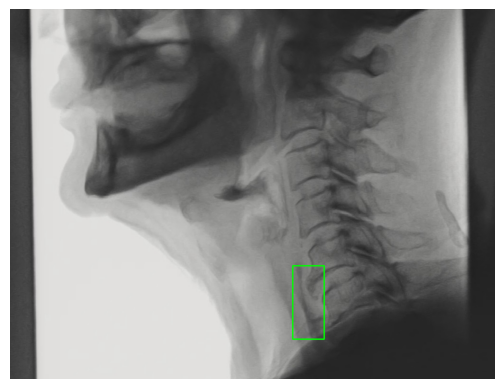

In [ ]:
import matplotlib.pyplot as plt
import cv2

# 원본 이미지를 가져오기
image = results[0].orig_img

# 탐지된 모든 박스에 대해 루프
for box in results[0].boxes.xyxy:
    x1, y1, x2, y2 = map(int, box[:4])
    # 이미지에 박스 그리기
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

# 이미지 시각화
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
# 결과 이미지를 파일로 저장
plt.savefig(fname="/content/drive/MyDrive/ultralytics/ultralytics/runs/predict/test_train7.jpg")
# 저장후, 보여주기. 순서가 바뀌면 빈 화면 저장하게 됌.
plt.show()

In [ ]:
# Run inference with the custom data trained RT-DETR-l model on the test x-ray image.
results_2 = model("/content/drive/MyDrive/ultralytics/ultralytics/assets/test_full.jpg")


image 1/1 /content/drive/MyDrive/ultralytics/ultralytics/assets/test_full.jpg: 1088x1088 1 Food, 47.0ms
Speed: 7.2ms preprocess, 47.0ms inference, 0.7ms postprocess per image at shape (1, 3, 1088, 1088)


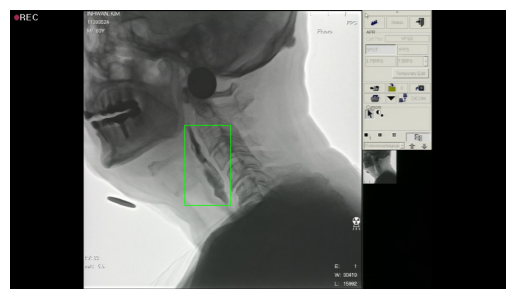

In [ ]:
import matplotlib.pyplot as plt
import cv2

# 원본 이미지를 가져오기
image = results_2[0].orig_img

# 탐지된 모든 박스에 대해 루프
for box in results_2[0].boxes.xyxy:
    x1, y1, x2, y2 = map(int, box[:4])
    # 이미지에 박스 그리기
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

# 이미지 시각화
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
# 결과 이미지를 파일로 저장
plt.savefig(fname="/content/drive/MyDrive/ultralytics/ultralytics/runs/predict/testfull_train7.jpg")
# 저장후, 보여주기. 순서가 바뀌면 빈 화면 저장하게 됌.
plt.show()

## Train 8
- train7에서, 초기 학습 때 성능이 급격히 오르는 것을 그래프로 확인할 수 있어, warmup_epochs를 5에서 3으로 줄임.

In [ ]:
run = wandb.init(project="rt-detr-manual",
                 name = 'train8')

wandb: Currently logged in as: so0916a. Use `wandb login --relogin` to force relogin


In [ ]:
def main():

    # Define the arguments for the trainer
    args = dict(name='train8',
                data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml",
                model="/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train7/weights/last.pt",
                imgsz=1088,  # Image size for training
                epochs=50,  # Number of epochs to train the model
                batch=8,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                optimizer='AdamW',
                weight_decay=0.0005, # Changed from 0.001 -> 0.0005
                lr0=0.0001,
                lrf=0.005, # Changed from 0.0001 -> 0.005. 후반부 학습률이 더 완만하게 감소. 더 세밀하게 converge.
                verbose=True,
                seed=0,
                deterministic=False,
                hsv_h=0.0,  # Disable hue shift
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=0.0,  # Disable rotation
                translate=0.0,  # Disable translation
                scale=0.0,  # Disable scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                crop_fraction=1.0, # 1.0 means no crop
                close_mosaic=0,
                resume=False,
                amp=True,
                auto_augment= None,
                save_dir="/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train8",
                warmup_epochs=3,  # Changed from 5 -> 3.
                plots=False,  # Disable plotting -> Resource Efficiency Settings
                save=True)   # Disable intermediate checkpoint saving -> Resource Efficiency Settings

    wandb.config.update(args)

    # Initialize the trainer with the specified arguments
    trainer = RTDETRTrainer(overrides=args)

    # Train the model
    trainer.train()

if __name__ == "__main__":
  main()

engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train7/weights/last.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml, epochs=50, time=None, patience=100, batch=8, imgsz=1088, save=False, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train8, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=False, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_cr

100%|██████████| 755k/755k [00:00<00:00, 98.0MB/s]


TensorBoard: Start with 'tensorboard --logdir runs/detect/train8', view at http://localhost:6006/
WARNING ⚠️ no model scale passed. Assuming scale='x'.

                   from  n    params  module                                       arguments                     
  0                  -1  1     25792  ultralytics.nn.modules.block.HGStem          [3, 32, 64]                   
  1                  -1  6    259200  ultralytics.nn.modules.block.HGBlock         [64, 64, 128, 3, 6]           
  2                  -1  1      1408  ultralytics.nn.modules.conv.DWConv           [128, 128, 3, 2, 1, False]    
  3                  -1  6   1248256  ultralytics.nn.modules.block.HGBlock         [128, 128, 512, 3, 6]         
  4                  -1  6   1788928  ultralytics.nn.modules.block.HGBlock         [512, 128, 512, 3, 6, False, True]
  5                  -1  1      5632  ultralytics.nn.modules.conv.DWConv           [512, 512, 3, 2, 1, False]    
  6                  -1  6   2079232  ultraly

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 7528 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7528/7528 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed


...

      49/50      25.1G      0.179     0.2628    0.05266          9       1088: 100%|██████████| 941/941 [07:54<00:00,  1.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:23<00:00,  4.27it/s]


                   all       1595       1707      0.729      0.649      0.635      0.371

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


      50/50      25.1G     0.1767     0.2593    0.05204          8       1088: 100%|██████████| 941/941 [07:53<00:00,  1.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:23<00:00,  4.35it/s]


                   all       1595       1707      0.736      0.652      0.639      0.371

50 epochs completed in 7.474 hours.
Optimizer stripped from runs/detect/train8/weights/last.pt, 135.4MB


lr/pg0,█▅▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr/pg1,▃▆███▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁
lr/pg2,▃▆███▇▇▇▇▇▇▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁
metrics/mAP50(B),▁▅▅▆▇▇▇▇▇▇▇▇▇▇▇▇▇██▇█▇█▇███████████▇████
metrics/mAP50-95(B),▁▄▄▅▆▆▇▆▇▇▆▆▆▆▇▇██▇▇▇▇▇▇▇▇▇▇▇██████▇████
metrics/precision(B),▁▆▆▆▇▇▇█▇▇▇▇▇▇▇▇▇██▇▇▇▇▇██▇█▇█▇███▇██▇██
metrics/recall(B),▁▅▅▆▆▇▇▇▇▇▇▆▇▇▇█▇▇▇▇▇▇▇▇▇▇█▇█████▇█▇███▇
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/cls_loss,█▆▅▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁


In [ ]:
model_val8 = RTDETR("/content/drive/MyDrive/ultralytics/ultralytics/runs_food_rtdetr/detect/train8/weights/last.pt")
metrics = model_val8.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
rt-detr-x summary: 646 layers, 65,469,491 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:45<00:00,  2.20it/s]


                   all       1595       1707      0.719      0.663      0.639       0.37
Speed: 0.7ms preprocess, 17.6ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to runs/detect/val2


{'metrics/precision(B)': 0.7194716776229895,
 'metrics/recall(B)': 0.6625857084039882,
 'metrics/mAP50(B)': 0.6386998862323362,
 'metrics/mAP50-95(B)': 0.37024551126008887,
 'fitness': 0.3970909487573136}

## Train 9

In [ ]:
run = wandb.init(project="rt-detr-manual",
                 name = 'train9',
                 resume = 'allow',
                 id='9omxuim9')

In [ ]:
def main():

    # Define the arguments for the trainer
    args = dict(name='train9',
                data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml",
                model="/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train7/weights/last.pt",
                imgsz=1088,
                epochs=60,  # Increased epochs for further learning
                batch=8,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                optimizer='AdamW',
                weight_decay=0.0005, # Lower weight decay for X-ray data
                lr0=0.0001,
                lrf=0.001, # Slower learning rate decay for precision
                warmup_epochs=5,  # Increased warmup for smoother start
                warmup_bias_lr=0.05,
                momentum=0.9,
                verbose=True,
                seed=0,
                deterministic=False,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                label_smoothing=0.00,
                close_mosaic=0,
                resume=False,
                amp=True,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir="/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train9",
                plots=False)  # Disable plotting -> Resource Efficiency Settings

    wandb.config.update(args)

    # Initialize the trainer with the specified arguments
    trainer = RTDETRTrainer(overrides=args)
    print("Using device:", args['device']) # Double-Check device setting
    trainer.train() # Start Trainer

if __name__ == "__main__":
  main()

engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train7/weights/last.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml, epochs=60, time=None, patience=100, batch=8, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train93, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=False, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_cr

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 7528 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7528/7528 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed


albumentations: 


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

...

      60/60      24.7G     0.2559     0.3233    0.07348          9       1088: 100%|██████████| 941/941 [07:56<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:23<00:00,  4.33it/s]


                   all       1595       1707      0.714      0.694      0.677      0.349

60 epochs completed in 8.910 hours.
Optimizer stripped from runs/detect/train93/weights/last.pt, 135.4MB
Optimizer stripped from runs/detect/train93/weights/best.pt, 135.4MB

Validating runs/detect/train93/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
rt-detr-x summary: 646 layers, 65,469,491 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:21<00:00,  4.65it/s]


                   all       1595       1707      0.747      0.684      0.686       0.37
Speed: 0.3ms preprocess, 10.8ms inference, 0.0ms loss, 0.3ms postprocess per image


lr/pg0,█▆▅▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr/pg1,▂▄▅▇███▇▇▇▇▇▇▇▆▆▆▆▆▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▁▁
lr/pg2,▂▄▅███▇▇▇▇▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁
metrics/mAP50(B),▁▄▅▇▆▇▇▇▇▆▇▆▇▇▇█▇▇▇▇▇▇▇▇▇██▇▇▇▇▇▇███████
metrics/mAP50-95(B),▁▂▃▅▄▆▅▅▆▅▄▆▆▅▅▅▇▇▆▆▆▆▆▅▆▅▇▇█▇▆▇▇▇▇▇▇▇▇▇
metrics/precision(B),▁▅▆▆▇▇▇▇▆▇█▇▇▇▇▇▇▇█▇▇▇█████▇█▇▇█▇███████
metrics/recall(B),▁▅▆▆▇▇▆▆▇▅▇▇▇▆▇▇█▇▇▇▆▇▇▇▇█▇██▇▇█████████
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/cls_loss,█▇▇▇▆▅▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁


In [ ]:
model_val9 = RTDETR("/content/drive/MyDrive/ultralytics/ultralytics/runs_food_rtdetr/detect/train9/weights/best.pt")
metrics = model_val9.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
rt-detr-x summary: 646 layers, 65,469,491 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:35<00:00,  2.84it/s]


                   all       1595       1707       0.74       0.69      0.686      0.371
Speed: 0.7ms preprocess, 17.5ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to runs/detect/val3


{'metrics/precision(B)': 0.7398649780566108,
 'metrics/recall(B)': 0.690099589923843,
 'metrics/mAP50(B)': 0.6858015176513577,
 'metrics/mAP50-95(B)': 0.371192829785509,
 'fitness': 0.4026536985720939}

## Logging과 Callback

- logging과 callback 추가하기 => 이미 Ultralytics에서 제공하는 코드에 포함되어 있음.
  - callback 레퍼런스 페이지:
    - https://docs.ultralytics.com/usage/callbacks/#returning-additional-information-with-prediction
    - https://docs.ultralytics.com/reference/engine/model/#ultralytics.engine.model.Model.add_callback

## Train10

 CosineAnnealingLR
- Cosine annealing scheduler: starts after the warm-up phase
- Warm-up epochs: gradually increase the learning rate for the first 5 epochs
- CosineAnnealingLR -> ```cos_lr=True```
  - reference:
  https://github.com/ultralytics/ultralytics/issues/6256
- 나중에 시도해보기
  - reference:
https://github.com/ultralytics/ultralytics/issues/2721

In [8]:
run = wandb.init(project="Food_rt-detr-manual",
                 name = 'train10')

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


In [ ]:
def main():

    # Define the arguments for the trainer
    args = dict(name='train10',
                data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/rtdetr_data.yaml",
                model=model_X,
                imgsz=1088,
                epochs=120,  # Increased epochs for further learning
                batch=8,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                deterministic=False,
                cos_lr = True,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                label_smoothing=0.00,
                close_mosaic=0,
                resume=False,
                amp=True,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir="/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train10",
                plots=False)  # Disable plotting -> Resource Efficiency Settings

    wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting

    results = model_X.train(**args) # Pass args during training

if __name__ == "__main__":
  main()

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.65 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=RTDETR(
  (model): DetectionModel(
    (model): Sequential(
      (0): HGStem(
        (stem1): Conv(
          (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): ReLU(inplace=True)
        )
        (stem2a): Conv(
          (conv): Conv2d(32, 16, kernel_size=(2, 2), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): ReLU(inplace=True)
        )
        (stem2b): Conv(
          (conv): Conv2d(16, 32, kernel_size=(2, 2), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): ReLU(inplace=True)
        )

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 8062 images, 25 backgrounds, 0 corrupt: 100%|██████████| 8062/8062 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed


albumentations: 


/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.0 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

...

    120/120      24.4G     0.1505     0.2406    0.03915          7       1088: 100%|██████████| 1008/1008 [08:22<00:00,  2.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:22<00:00,  4.45it/s]


                   all       1595       1707       0.75      0.653      0.624       0.36

120 epochs completed in 18.245 hours.
Optimizer stripped from runs/detect/train103/weights/last.pt, 135.4MB
Optimizer stripped from runs/detect/train103/weights/best.pt, 135.4MB

Validating runs/detect/train103/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.11.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
rt-detr-x summary: 646 layers, 65,469,491 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:20<00:00,  4.78it/s]


                   all       1595       1707       0.73       0.67      0.633      0.362
Speed: 0.3ms preprocess, 10.7ms inference, 0.0ms loss, 0.3ms postprocess per image


lr/pg0,█████▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁
lr/pg1,█████████▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▃▂▂▂▂▂▂▁▁▁▁
lr/pg2,█████▇▇▇▇▇▇▇▇▆▆▆▆▆▅▅▄▄▄▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
metrics/mAP50(B),▆▄▁▄▃▄▄▃▄▃▄▅▅▃▅▆▅▆▆▇▆▇▄▆█▇▆▁▆▄██████████
metrics/mAP50-95(B),▄▂▃▄▃▄▄▁▄▄▄▆▄▆▅▆▆▅▆▃▇▇▅▄▅▄▅▅▆███████████
metrics/precision(B),▆▂▅▅▁▆▆▆▇▅▇▆▅▇▆▇▇▇▇▆▅█▇▇▆▆▇▇▇███████████
metrics/recall(B),▅▅▅▄▅▁▅▅▆▆▆▅▇▆▆▅▆██▇▇█▇██▇▅▇▇▅██████████
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/cls_loss,█▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁


# Sweep 사용하기

## Config Setting


Choosing the Right Metric:
  - If you want to focus on improving classification accuracy, then val/cls_loss is a good choice.
  - If you want to focus on better bounding box localization, consider val/giou_loss.
  - If smoothness or minimizing other spatial differences is important, you could optimize for val/l1_loss.

In [ ]:
# Sweep configuration for RT-DETR-l

sweep_config = {
    'name': 'sweepdemo',
    'method': 'grid',  # Can be 'grid', 'random', or 'bayes'
    'metric': {
        'name': 'metrics/mAP50-95(B)', # Ensure this matches your actual validation loss name (check wandb runs page)
        'goal': 'maximize'
    },
    'parameters': {
        "learning_rate": {'max': 0.1, 'min': 0.00001},
        'epochs': {'values': [5, 10, 15]},
        'batch_size': {'values': [1, 2, 4]}
    }
}

In [ ]:
# Initialize the Sweep.
sweep_id = wandb.sweep(sweep_config)

Create sweep with ID: a1j19lx8
Sweep URL: https://wandb.ai/so0916a/RT-DETR/sweeps/a1j19lx8


In [ ]:
def train():

  # Connect to the existing project with a new run
  wandb.init(project="rt-detr-manual")  # Specify the existing project name

  # Create a dynamic run name based on the sweep config values
  run_name = f"lr_{wandb.config.learning_rate}_epochs_{wandb.config.epochs}_batch_{wandb.config.batch_size}"
  wandb.run.name = run_name
  wandb.run.save()

  # Load a COCO-pretrained RT-DETR-l model
  model = RTDETR("/content/drive/MyDrive/음식_객체탐지/rtdetr-l.pt")

  # Train the model on the food dataset for 100 epochs
  results = model.train(
      data="/content/drive/MyDrive/음식_객체탐지/custom_data/rtdetr_data.yaml",
      epochs= wandb.config.epochs, # Dynamically adjust epochs from sweep
      imgsz=640,  # Image size is fixed, 640 or 1088
      workers=2,
      batch=wandb.config.batch_size,  # Dynamically adjust batch size from sweep
      amp=True)  # Disable AMP)

  # Extract performance metrics from the results
  mAP50 = results.metrics['mAP50']  # mAP at IoU 0.5
  mAP50_95 = results.metrics['mAP50-95']  # mAP averaged across IoU thresholds
  precision = results.metrics['precision']
  recall = results.metrics['recall']
  f1_score = results.metrics['f1']

  # Log these metrics to wandb
  wandb.log({
      "train_loss": results.metrics['train_loss'],
      "val_loss": results.metrics['val_loss'],
      "mAP50": mAP50,
      "mAP50-95": mAP50_95,
      "precision": precision,
      "recall": recall,
      "f1_score": f1_score
  })

In [ ]:
# Start the sweep agent and execute the training function for each run
wandb.agent(sweep_id, function=train)

# No 'count', will run through all configs automatically
#wandb.agent(sweep_id, function=train, count=10)  # Adjust 'count' for number of experiments

In [ ]:
wandb.mark_preempting()

In [ ]:
# Set the checkpoint path or disable resume
resume_checkpoint = False #'/content/drive/MyDrive/음식_객체탐지/runs/detect/train5/weights/best.pt'